In [2]:
from pymatgen.core import Structure
from pymatgen.io.vasp.sets import MPRelaxSet

s = Structure.from_file("Si.cif", primitive=True)
custom_settings = {"NELMIN": 5}  # user custom incar settings
relax = MPRelaxSet(s, user_incar_settings=custom_settings, user_potcar_functional="PBE_52")
relax.write_input("Si-relax")

In [3]:


from pymatgen.io.vasp import Vasprun

v = Vasprun("Si-relax/vasprun.xml")
print(v.final_energy)  # final total energy
s = v.final_structure
s.to(filename="Si-relax.cif")  # save relaxed structure into cif file
print(s)  # relaxed structure



-10.84131822 eV
Full Formula (Si2)
Reduced Formula: Si
abc   :   3.867334   3.867334   3.867334
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Si    0.75  0.75  0.75
  1  Si    0     0     0


In [6]:


from pymatgen.io.vasp.sets import MPStaticSet

custom_settings = {"NELM": 60}  # user custom incar settings
static = MPStaticSet.from_prev_calc(
    "Si-relax/", standardize=True, user_incar_settings=custom_settings, user_potcar_functional="PBE_52"
)
static.write_input("Si-static")



In [8]:
from pymatgen.io.vasp import Vasprun

v = Vasprun("Si-static/vasprun.xml")
print(v.final_energy)  # final total energy

-10.84608138 eV


In [10]:


from pymatgen.io.vasp.sets import MPNonSCFSet

# generate uniform k-points for DOS calc.
custom_settings = {"LAECHG": "False", "LVHAR": "False"}  # user custom incar settings
dos = MPNonSCFSet.from_prev_calc(
    "Si-static/",
    mode="uniform",
    reciprocal_density=200,
    user_incar_settings=custom_settings,
    user_potcar_functional="PBE_52"
)
dos.write_input("Si-dos")

# generate k-points along high symmetry line for band structure calc.
band = MPNonSCFSet.from_prev_calc(
    "Si-static/", mode="line", user_incar_settings=custom_settings, user_potcar_functional="PBE_52"
)
band.write_input("Si-band")



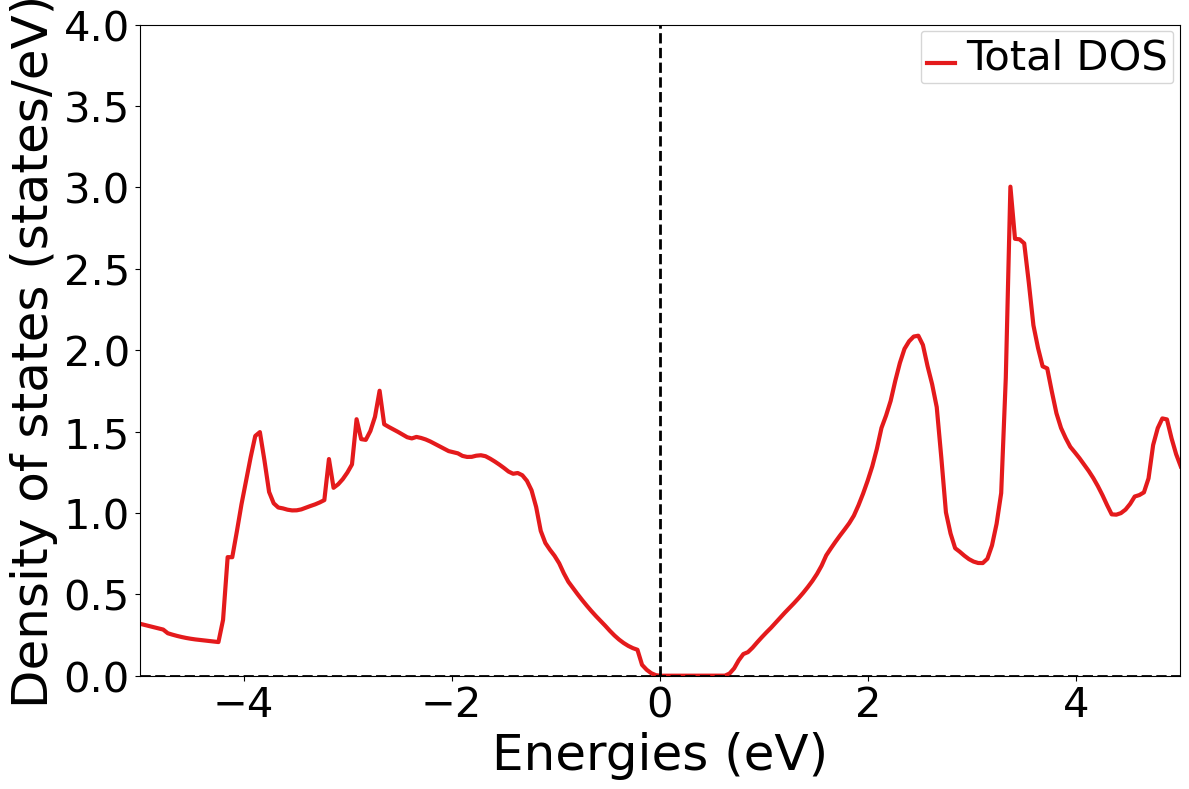

In [11]:
%matplotlib inline
from pymatgen.electronic_structure.plotter import DosPlotter
from pymatgen.io.vasp import Vasprun

v = Vasprun("Si-dos/vasprun.xml")
tdos = v.tdos
plotter = DosPlotter()
plotter.add_dos("Total DOS", tdos)
plotter.show(xlim=[-5, 5], ylim=[0, 4])



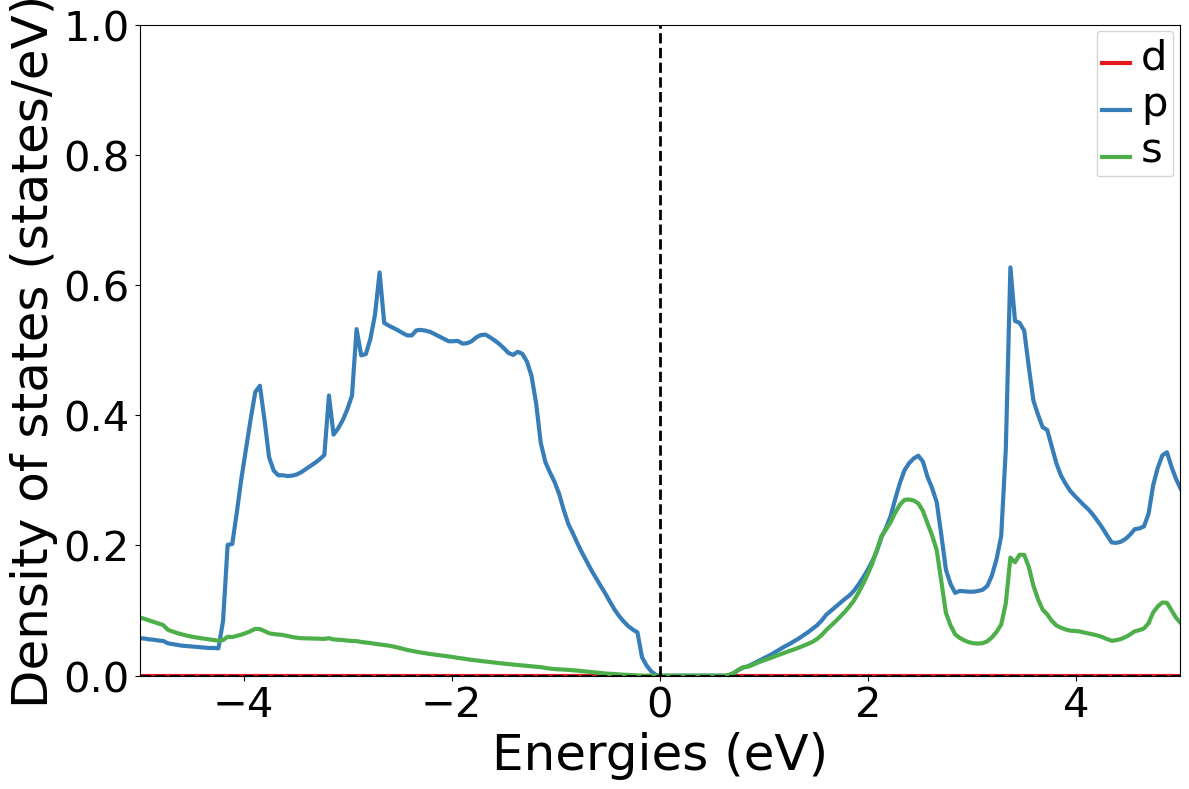

In [12]:


%matplotlib inline
from pymatgen.electronic_structure.plotter import DosPlotter
from pymatgen.io.vasp import Vasprun

v = Vasprun("Si-dos/vasprun.xml")
cdos = v.complete_dos
spd_dos = cdos.get_spd_dos()
plotter = DosPlotter()
plotter.add_dos_dict(spd_dos)
plotter.show(xlim=[-5, 5], ylim=[0, 1])



<Axes: xlabel='$\\mathrm{Wave\\ Vector}$', ylabel='$\\mathrm{E\\ -\\ E_f\\ (eV)}$'>

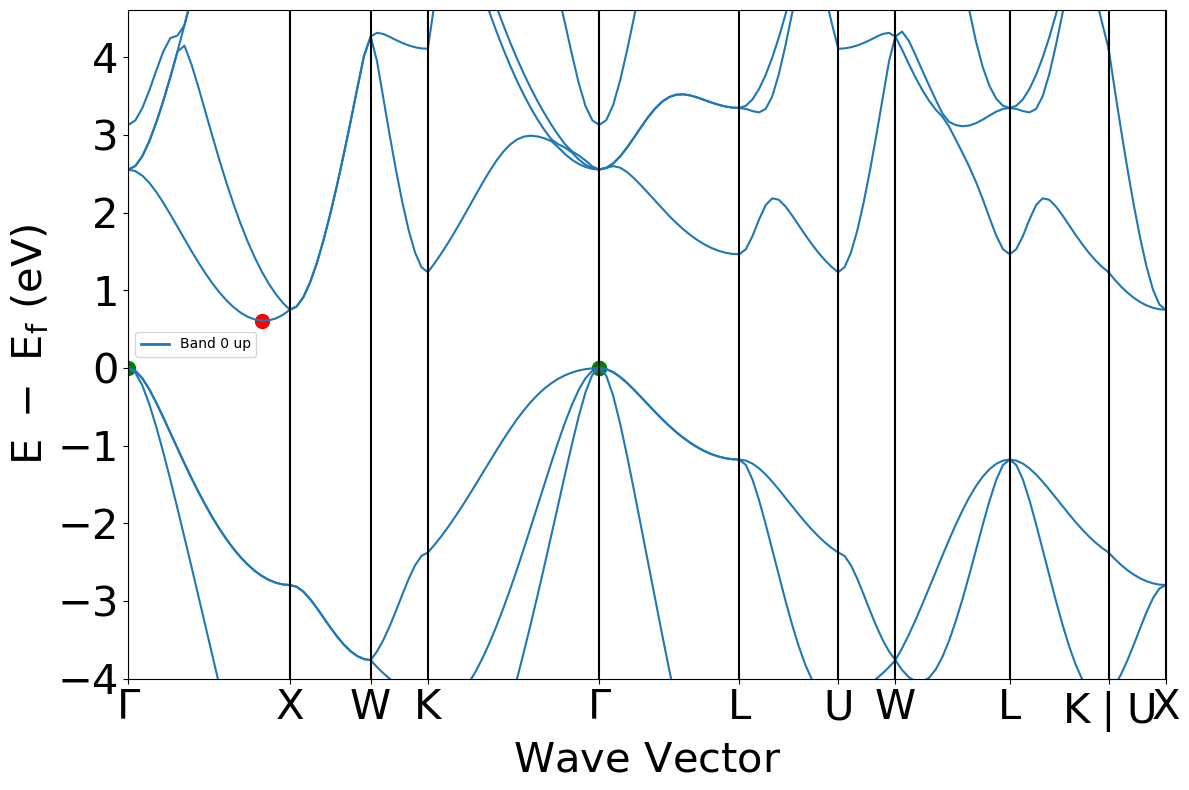

In [14]:
%matplotlib inline
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.io.vasp import BSVasprun, Vasprun

v = BSVasprun("Si-band/vasprun.xml")
bs = v.get_band_structure(kpoints_filename="Si-band/KPOINTS", line_mode=True)
plt = BSPlotter(bs)
plt.get_plot(vbm_cbm_marker=True)

